<a href="https://colab.research.google.com/github/rix031110/Projects/blob/main/TGTG_Business_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
file_path= '/content/drive/MyDrive/Università/DATA SCIENCE FOR MANAGEMENT UNICATT/Analytical Base Table.xlsx'
df= pd.read_excel(file_path, header=0)

df.head(5)

,IPAddress,RecordedDate,Q1,Q2,Q3_1,Q3_2,Q3_3,Q3_4,Q3_5,Q3_6,...,Q22_6,Q22_7,Q22_8,Q23,Gender,Q25,Q26,Q27,Q28,Q29
0,93.34.233.131,2023-03-09 13:59:28,1,1,NaN,NaN,1.0,NaN,NaN,NaN,...,3,4,2,51,2,1,3,4,5,2.0
1,79.54.98.108,2023-03-09 15:44:57,1,1,NaN,NaN,1.0,NaN,NaN,1.0,...,5,5,5,60,2,1,3,4,3,4.0
2,93.47.231.10,2023-03-27 07:26:22,1,1,1.0,1.0,1.0,1.0,NaN,1.0,...,1,1,1,57,2,1,3,4,4,2.0
3,93.70.21.70,2023-03-27 18:10:44,1,1,1.0,1.0,NaN,NaN,NaN,NaN,...,1,1,1,22,2,1,1,3,3,5.0
4,95.74.34.99,2023-04-04 12:27:45,1,1,1.0,NaN,NaN,NaN,1.0,NaN,...,9,7,6,30,2,1,3,5,2,5.0


#DATA CLEANING
#Keeping only the answers


In [7]:
used_columns = [
    'Q1', 'Q2', 'Q3_1', 'Q3_2', 'Q3_3', 'Q3_4',
       'Q3_5', 'Q3_6', 'Q3_7', 'Q4_1', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9_1', 'Q9_2',
       'Q9_3', 'Q9_4', 'Q9_5', 'Q9_6', 'Q9_7', 'Q9_8', 'Q10', 'Q11_1', 'Q12_1',
       'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5', 'Q13', 'Q14', 'Q15', 'Q16_1',
       'Q16_2', 'Q16_3', 'Q16_4', 'Q16_5', 'Q16_6', 'Q16_7', 'Q16_8', 'Q17_1',
       'Q17_2', 'Q17_3', 'Q17_4', 'Q17_5', 'Q17_6', 'Q17_7', 'Q18', 'Q19',
       'Q20', 'Q21', 'Q22_1', 'Q22_2', 'Q22_3', 'Q22_4', 'Q22_5', 'Q22_6',
       'Q22_7', 'Q22_8', 'Q23', 'Gender', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29'

]

used_columns = [col for col in used_columns if col in df.columns]


df1 = df[used_columns]
df=df1.rename(columns={'Gender':'Q24'})
df.head()


,Q1,Q2,Q3_1,Q3_2,Q3_3,Q3_4,Q3_5,Q3_6,Q3_7,Q4_1,...,Q22_6,Q22_7,Q22_8,Q23,Q24,Q25,Q26,Q27,Q28,Q29
0,1,1,NaN,NaN,1.0,NaN,NaN,NaN,1.0,6,...,3,4,2,51,2,1,3,4,5,2.0
1,1,1,NaN,NaN,1.0,NaN,NaN,1.0,NaN,8,...,5,5,5,60,2,1,3,4,3,4.0
2,1,1,1.0,1.0,1.0,1.0,NaN,1.0,NaN,10,...,1,1,1,57,2,1,3,4,4,2.0
3,1,1,1.0,1.0,NaN,NaN,NaN,NaN,NaN,8,...,1,1,1,22,2,1,1,3,3,5.0
4,1,1,1.0,NaN,NaN,NaN,1.0,NaN,NaN,6,...,9,7,6,30,2,1,3,5,2,5.0


##Cleaning the null values



In [8]:
print('===MISSING VALUES===')
pd.set_option('display.max_rows', None)
print(df.isnull().sum())
pd.reset_option('display.max_rows')

===MISSING VALUES===
Q1         0
Q2         0
Q3_1      96
Q3_2     164
Q3_3      91
Q3_4     237
Q3_5     187
Q3_6     186
Q3_7     280
Q4_1       0
Q5         0
Q6         0
Q7         0
Q8         0
Q9_1       0
Q9_2       0
Q9_3       0
Q9_4       0
Q9_5       0
Q9_6       0
Q9_7       0
Q9_8       0
Q10        0
Q11_1      0
Q12_1      0
Q12_2      0
Q12_3      0
Q12_4      0
Q12_5      0
Q13        0
Q14        0
Q15        0
Q16_1      0
Q16_2      0
Q16_3      0
Q16_4      0
Q16_5      0
Q16_6      0
Q16_7      0
Q16_8      0
Q17_1      0
Q17_2      0
Q17_3      0
Q17_4      0
Q17_5      0
Q17_6      0
Q17_7      0
Q18        0
Q19        0
Q20        0
Q21        0
Q22_1      0
Q22_2      0
Q22_3      0
Q22_4      0
Q22_5      0
Q22_6      0
Q22_7      0
Q22_8      0
Q23        0
Q24        0
Q25        0
Q26        0
Q27        0
Q28        0
Q29       49
dtype: int64


In [9]:
df[df.isnull().any(axis=1)]
df['Q3_1']=df['Q3_1'].fillna(0)
df['Q3_2']=df['Q3_2'].fillna(0)
df['Q3_3']=df['Q3_3'].fillna(0)
df['Q3_4']=df['Q3_4'].fillna(0)
df['Q3_5']=df['Q3_5'].fillna(0)
df['Q3_6']=df['Q3_6'].fillna(0)
df['Q3_7']=df['Q3_7'].fillna(0)
df['Q29']= df['Q29'].fillna(0)
df

,Q1,Q2,Q3_1,Q3_2,Q3_3,Q3_4,Q3_5,Q3_6,Q3_7,Q4_1,...,Q22_6,Q22_7,Q22_8,Q23,Q24,Q25,Q26,Q27,Q28,Q29
0,1,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,6,...,3,4,2,51,2,1,3,4,5,2.0
1,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,8,...,5,5,5,60,2,1,3,4,3,4.0
2,1,1,1.0,1.0,1.0,1.0,0.0,1.0,0.0,10,...,1,1,1,57,2,1,3,4,4,2.0
3,1,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,8,...,1,1,1,22,2,1,1,3,3,5.0
4,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,6,...,9,7,6,30,2,1,3,5,2,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,...,6,5,4,51,2,1,4,3,2,4.0
290,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,...,6,5,4,53,1,1,4,2,2,2.0
291,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,...,6,5,4,53,1,1,3,2,2,2.0
292,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,...,9,8,6,44,1,1,4,4,2,4.0


#What are the attitudes of consumers toward food waste in italian homes?


### Individual Histogram Plots for Q12 Questions

In [19]:
q12_columns = ['Q12_1', 'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5']

# Determine the overall min and max score across all Q12 questions for consistent x-axis
overall_min_score = df[q12_columns].min().min()
overall_max_score = df[q12_columns].max().max()

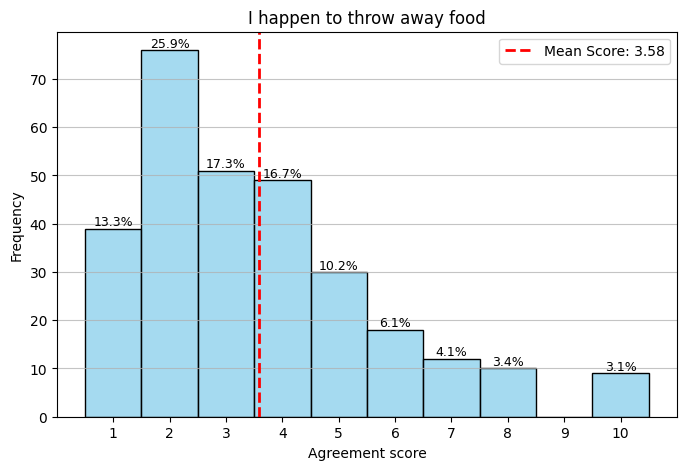

In [20]:
col = 'Q12_1'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('I happen to throw away food')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

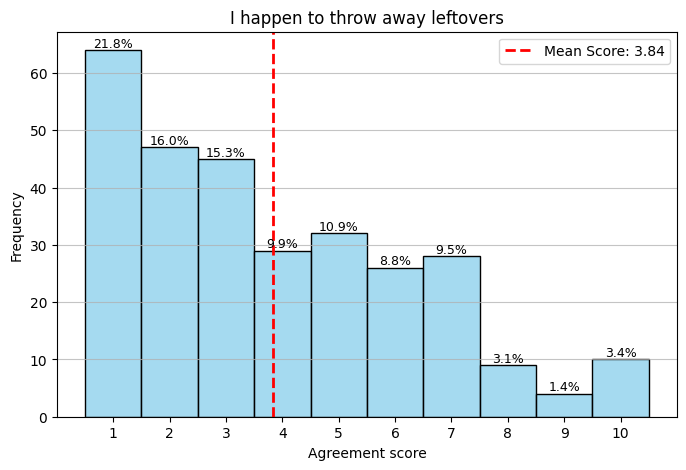

In [12]:
col = 'Q12_2'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('I happen to throw away leftovers')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

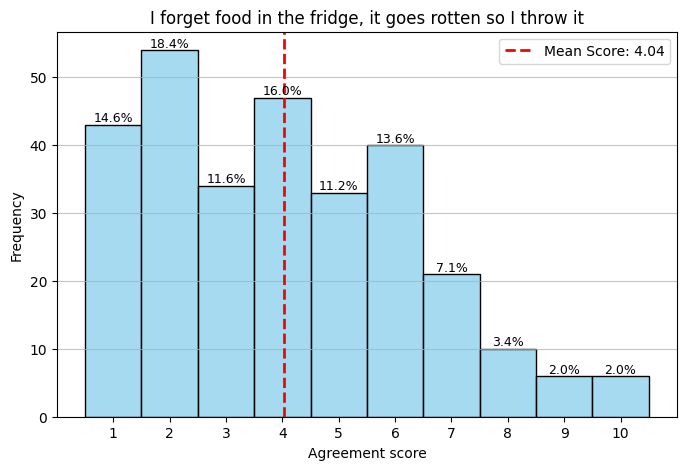

In [13]:
col = 'Q12_3'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('I forget food in the fridge, it goes rotten so I throw it')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

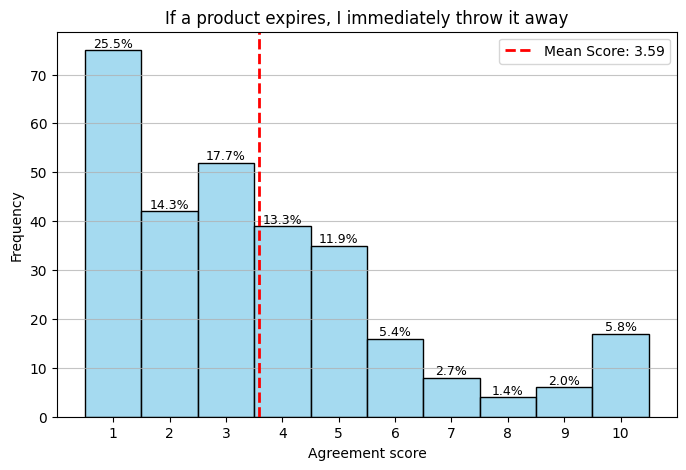

In [14]:
col = 'Q12_4'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('If a product expires, I immediately throw it away')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

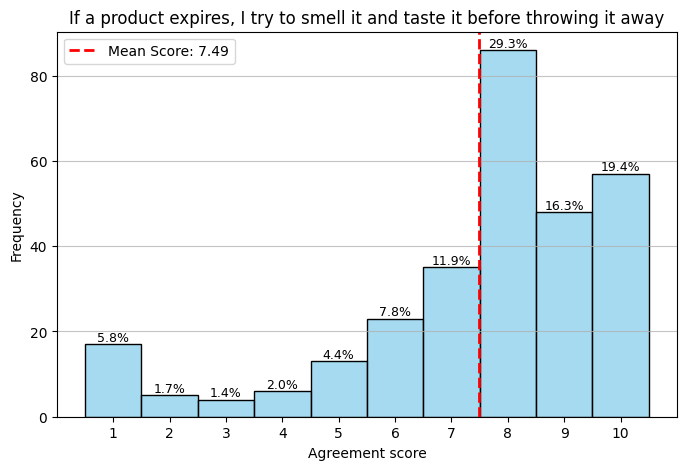

In [15]:
col = 'Q12_5'
plt.figure(figsize=(8, 5))
ax = sns.histplot(df[col], bins=np.arange(overall_min_score, overall_max_score + 2) - 0.5, kde=False, color='skyblue', edgecolor='black', stat='count')
plt.title('If a product expires, I try to smell it and taste it before throwing it away')
plt.xlabel('Agreement score')
plt.ylabel('Frequency')
plt.xticks(range(int(overall_min_score), int(overall_max_score) + 1))
plt.grid(axis='y', alpha=0.75)


mean_score_x = df[col].mean()
plt.axvline(x=mean_score_x, color='red', linestyle='--', linewidth=2, label=f'Mean Score: {mean_score_x:.2f}')
plt.legend()

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df[col])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

### Mean, Median and Standard Deviation Values for Q12 Questions

In [16]:
q12_columns = ['Q12_1', 'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5']
combined_q12_stats = pd.DataFrame({
    'Mean': df[q12_columns].mean().round(2),
    'Median': df[q12_columns].median().round(2),
    'Std': df[q12_columns].std().round(2)
})
display(combined_q12_stats)

,Mean,Median,Std
Q12_1,3.58,3.0,2.14
Q12_2,3.84,3.0,2.47
Q12_3,4.04,4.0,2.30
Q12_4,3.59,3.0,2.51
Q12_5,7.49,8.0,2.37


##Relation between age and food waste behaviours

###Age analysis

In [22]:
bins = np.append(np.arange(min_age, 60, 10), max_age + 1)
frequency_table_q23 = pd.cut(df['Q23'], bins=bins, right=False, include_lowest=True).value_counts().sort_index()

# Convert to DataFrame and calculate percentages
frequency_table_q23 = frequency_table_q23.to_frame(name='Frequency')
frequency_table_q23['Percentage'] = (frequency_table_q23['Frequency'] / len(df)) * 100
frequency_table_q23['Percentage'] = frequency_table_q23['Percentage'].map(lambda x: f'{x:.2f}%')

display(frequency_table_q23)

,Frequency,Percentage
Q23,,
"[19, 29)",136,46.26%
"[29, 39)",40,13.61%
"[39, 49)",54,18.37%
"[49, 59)",52,17.69%
"[59, 71)",12,4.08%


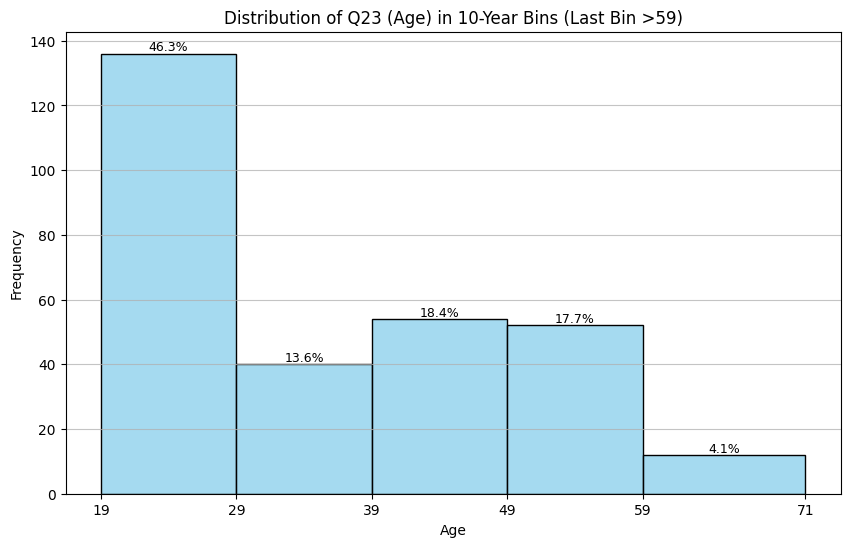

In [21]:
min_age = df['Q23'].min()
max_age = df['Q23'].max()

# Create 10-year bins up to 59, then a single bin for >59
# The upper bound for the last bin needs to be max_age + 1 to include max_age
bins = np.append(np.arange(min_age, 60, 10), max_age + 1)

plt.figure(figsize=(10, 6))
ax = sns.histplot(df['Q23'], kde=False, bins=bins, color='skyblue', edgecolor='black', stat='count')
plt.title('Distribution of Q23 (Age) in 10-Year Bins (Last Bin >59)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.xticks(bins)
plt.grid(axis='y', alpha=0.75)

for patch in ax.patches:
    x = patch.get_x() + patch.get_width() / 2
    count = patch.get_height()
    total_count = len(df['Q23'])
    percentage = (count / total_count) * 100
    if count > 0:
        ax.text(x, count, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.show()

###Linear relation?

In [28]:
q12_columns = ['Q12_1', 'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5']

# Ensure Q23 is treated as categorical for the contingency table
# Assuming 'bins' and 'df['Q23_binned']' are already defined from previous steps

df['Q23_binned'] = pd.cut(df['Q23'], bins=bins, right=False, include_lowest=True)

for col in q12_columns:
    print(f"\nContingency Table (Percentages) for Q23 (Age Bins) and {col}:\n")
    contingency_table = pd.crosstab(df['Q23_binned'], df[col])
    # Calculate percentages for each row (age bin)
    contingency_table_percentage = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
    display(contingency_table_percentage.round(2).astype(str))


Contingency Table (Percentages) for Q23 (Age Bins) and Q12_1:



Q12_1,1,2,3,4,5,6,7,8,10
Q23_binned,,,,,,,,,
"[19, 29)",15.44,19.12,19.85,10.29,13.97,8.82,5.88,3.68,2.94
"[29, 39)",5.0,27.5,27.5,25.0,10.0,2.5,2.5,0.0,0.0
"[39, 49)",5.56,25.93,22.22,27.78,9.26,1.85,3.7,3.7,0.0
"[49, 59)",19.23,42.31,1.92,17.31,3.85,5.77,1.92,3.85,3.85
"[59, 71)",25.0,25.0,0.0,8.33,0.0,8.33,0.0,8.33,25.0



Contingency Table (Percentages) for Q23 (Age Bins) and Q12_2:



Q12_2,1,2,3,4,5,6,7,8,9,10
Q23_binned,,,,,,,,,,
"[19, 29)",16.18,20.59,15.44,8.82,8.09,8.09,12.5,4.41,0.74,5.15
"[29, 39)",22.5,7.5,15.0,12.5,20.0,10.0,10.0,0.0,2.5,0.0
"[39, 49)",22.22,9.26,16.67,12.96,16.67,14.81,3.7,1.85,1.85,0.0
"[49, 59)",40.38,17.31,13.46,7.69,1.92,5.77,9.62,1.92,0.0,1.92
"[59, 71)",0.0,16.67,16.67,8.33,25.0,0.0,0.0,8.33,8.33,16.67



Contingency Table (Percentages) for Q23 (Age Bins) and Q12_3:



Q12_3,1,2,3,4,5,6,7,8,9,10
Q23_binned,,,,,,,,,,
"[19, 29)",19.12,15.44,9.56,19.12,4.41,15.44,8.09,3.68,2.21,2.94
"[29, 39)",2.5,17.5,10.0,22.5,15.0,25.0,5.0,2.5,0.0,0.0
"[39, 49)",14.81,14.81,12.96,14.81,16.67,11.11,9.26,3.7,1.85,0.0
"[49, 59)",11.54,28.85,15.38,7.69,21.15,5.77,3.85,3.85,1.92,0.0
"[59, 71)",16.67,25.0,16.67,0.0,8.33,0.0,8.33,0.0,8.33,16.67



Contingency Table (Percentages) for Q23 (Age Bins) and Q12_4:



Q12_4,1,2,3,4,5,6,7,8,9,10
Q23_binned,,,,,,,,,,
"[19, 29)",20.59,11.03,17.65,15.44,8.82,7.35,2.94,2.94,2.94,10.29
"[29, 39)",22.5,20.0,20.0,20.0,12.5,2.5,2.5,0.0,0.0,0.0
"[39, 49)",20.37,20.37,18.52,16.67,12.96,3.7,1.85,0.0,1.85,3.7
"[49, 59)",44.23,13.46,17.31,0.0,19.23,1.92,0.0,0.0,1.92,1.92
"[59, 71)",33.33,8.33,8.33,8.33,8.33,16.67,16.67,0.0,0.0,0.0



Contingency Table (Percentages) for Q23 (Age Bins) and Q12_5:



Q12_5,1,2,3,4,5,6,7,8,9,10
Q23_binned,,,,,,,,,,
"[19, 29)",8.82,1.47,2.94,2.21,4.41,11.76,12.5,27.21,13.97,14.71
"[29, 39)",0.0,0.0,0.0,2.5,0.0,7.5,7.5,37.5,37.5,7.5
"[39, 49)",5.56,5.56,0.0,1.85,3.7,3.7,16.67,37.04,14.81,11.11
"[49, 59)",0.0,0.0,0.0,0.0,7.69,0.0,11.54,26.92,9.62,44.23
"[59, 71)",16.67,0.0,0.0,8.33,8.33,16.67,0.0,0.0,8.33,41.67


In [24]:
q12_columns = ['Q12_1', 'Q12_2', 'Q12_3', 'Q12_4', 'Q12_5']

print("Pearson's Correlation (rho) between Q23 (Age) and Q12_x questions:\n")

for col in q12_columns:
    # Calculate Pearson's correlation coefficient
    # df.corr() computes pairwise correlation of columns
    correlation = df['Q23'].corr(df[col])
    print(f"  Q23 vs. {col}: {correlation:.3f}")


Pearson's Correlation (rho) between Q23 (Age) and Q12_x questions:

  Q23 vs. Q12_1: -0.041
  Q23 vs. Q12_2: -0.063
  Q23 vs. Q12_3: -0.018
  Q23 vs. Q12_4: -0.222
  Q23 vs. Q12_5: 0.182


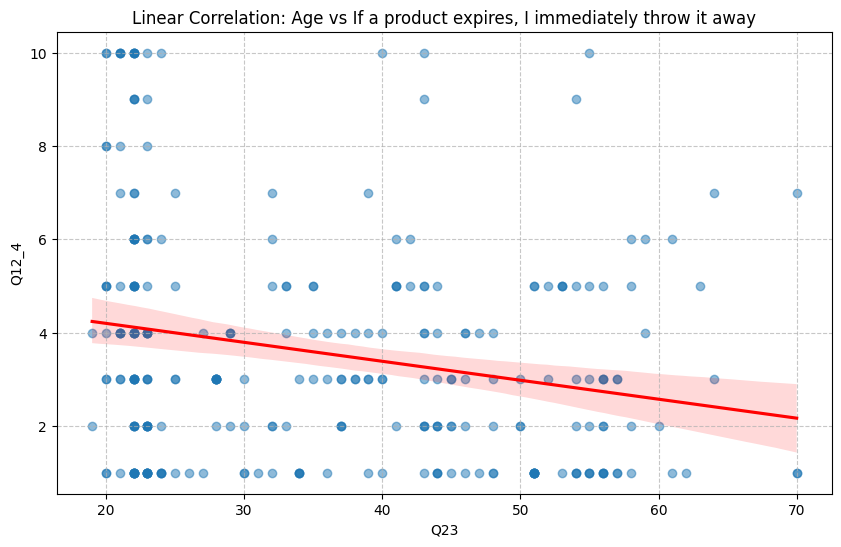

In [25]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Q23', y='Q12_4', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Linear Correlation: Age vs If a product expires, I immediately throw it away')
plt.xlabel('Q23')
plt.ylabel('Q12_4')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

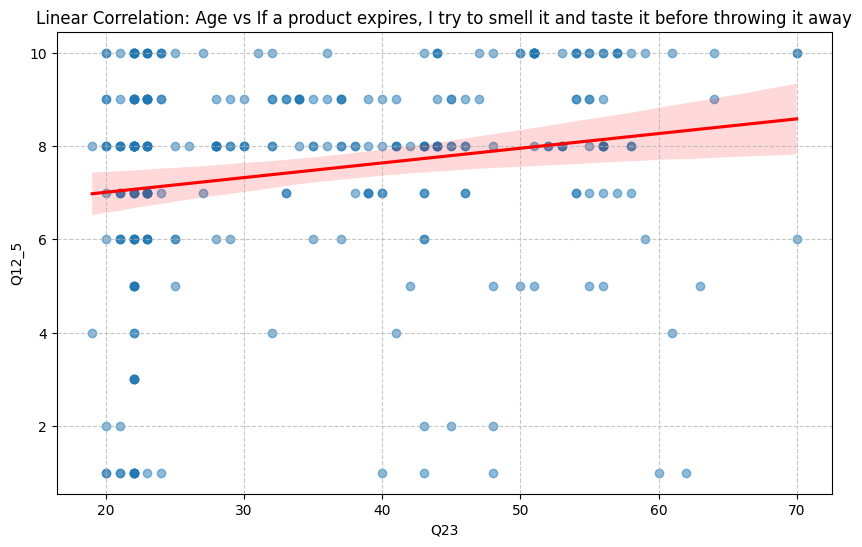

In [26]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Q23', y='Q12_5', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Linear Correlation: Age vs If a product expires, I try to smell it and taste it before throwing it away')
plt.xlabel('Q23')
plt.ylabel('Q12_5')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [29]:
# Define the two age groups for comparison using pandas.Interval objects
# These intervals match the bins created earlier for 'Q23_binned'
group1_age_interval = pd.Interval(left=19, right=29, closed='left')
group2_age_interval = pd.Interval(left=59, right=71, closed='left')

# Filter the DataFrame for each group based on the Q23_binned column
q12_4_group1 = df[df['Q23_binned'] == group1_age_interval]['Q12_4']
q12_4_group2 = df[df['Q23_binned'] == group2_age_interval]['Q12_4']

print(f"Comparing mean Q12_4 scores between age group {group1_age_interval} and {group2_age_interval}")

# Check if both groups have enough data for a t-test
if len(q12_4_group1) > 1 and len(q12_4_group2) > 1:
    # Perform independent samples t-test (Welch's t-test, as it doesn't assume equal variances)
    t_stat, p_value = stats.ttest_ind(q12_4_group1,q12_4_group2, equal_var=False)

    print(f"\nMean Q12_4 for age group {group1_age_interval}: {q12_4_group1.mean():.2f}")
    print(f"Mean Q12_4 for age group {group2_age_interval}: {q12_4_group2.mean():.2f}")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print("Alpha: 0.05")
    print(f"Degrees of Freedom: {len(q12_4_group1) + len(q12_4_group2) - 2}")

    alpha = 0.05
    if p_value < alpha:
        print(f"\nConclusion: With a p-value of {p_value:.3f}, which is less than {alpha}, we reject the null hypothesis.")
    else:
        print(f"\nConclusion: With a p-value of {p_value:.3f}, which is greater than {alpha}, we fail to reject the null hypothesis.")
else:
    print("One or both selected age groups do not have enough data to perform a t-test. Please ensure groups have at least 2 observations.")


Comparing mean Q12_4 scores between age group [19, 29) and [59, 71)

Mean Q12_4 for age group [19, 29): 4.19
Mean Q12_4 for age group [59, 71): 3.67
T-statistic: 0.698
P-value: 0.497
Alpha: 0.05
Degrees of Freedom: 146

Conclusion: With a p-value of 0.497, which is greater than 0.05, we fail to reject the null hypothesis.


#Drivers of consumers how are usign the food wasting apps
